# NB2: Feature Engineering

In NB1 we used the raw sensor readings directly.
Here we transform them: encode the cyclic variables (time of day, season, longitude)
as sine/cosine pairs, and add lagged versions of the ionospheric TEC signal.

The model, split, and metrics are the same as NB1, so you can compare the scores directly.

In [ ]:
# ============================================================
# Colab setup — run this cell FIRST. Does nothing when run locally.
#
# Before running: upload grace_workshop_small.parquet into the Colab Files
# pane (folder icon on the left) so it lands at /content/.
# (Or use grace_workshop.parquet for the full 480MB file.)
# ============================================================
import os, sys, shutil

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # 1) Clone the repo for the code modules (feature_functions.py, paths.py, Forecast/, ...)
    if not os.path.exists("/content/ML_TND"):
        os.system("git clone -q https://github.com/lotteat11/ML_TND /content/ML_TND")

    # 2) Install Python deps
    os.system("pip install -q xgboost scikit-learn pyarrow joblib")

    # 3) Move the parquet you uploaded (/content/grace_workshop_small.parquet) into the repo
    src  = "/content/grace_workshop_small.parquet"
    dest = "/content/ML_TND/grace_workshop.parquet"
    if os.path.exists(src) and not os.path.exists(dest):
        shutil.move(src, dest)
    if not os.path.exists(dest):
        raise FileNotFoundError(
            "grace_workshop_small.parquet not found. Upload it via the Colab Files "
            "pane (it should appear at /content/grace_workshop_small.parquet), then re-run this cell."
        )

    # 4) Work from the workshop/ folder so all relative paths resolve
    os.chdir("/content/ML_TND/workshop")
    print("Colab setup complete — CWD:", os.getcwd())
else:
    print("Local run — no Colab setup needed.")


In [42]:
# Install required packages — safe to run even if already installed
%pip install -q xgboost scikit-learn pandas numpy matplotlib scipy joblib pyarrow

Python(39653) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Load libraries, including the project's feature engineering functions from `feature_functions.py`.

In [43]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import feature_functions as ff
from paths import GRACE_WORKSHOP as GRACE_MERGED

Load the dataset, compute the log-ratio target, and compute raw LST for the discontinuity demo.

In [30]:
df = pd.read_parquet(GRACE_MERGED)
df['time'] = pd.to_datetime(df['grace_time'])
df = df[(df['time'] > '2009-06-01') & (df['time'] < '2016-01-01')].sort_values('time').reset_index(drop=True)

# Drop any non-positive densities before taking the log
df = df[(df['rho_obs'] > 0) & (df['msis_rho'] > 0)].reset_index(drop=True)
df['log_ratio'] = np.log(df['rho_obs'] / df['msis_rho'])
print(f'Loaded {len(df):,} rows')

Loaded 3,984,449 rows


## 1. Cyclic encoding

Longitude, Day-of-Year and Local Solar Time are all **circular**: they wrap around.
Longitude jumps from +180° to −180°, DOY from 366 back to 1, LST from 24 back to 0.
A gradient boosted tree splits on numerical thresholds, so it sees these wrap points
as large jumps even though they are physically adjacent.

Encoding each as a (sin, cos) pair removes the jump: the two curves below trace the
full cycle smoothly, and together they give every position a unique (sin, cos) coordinate.

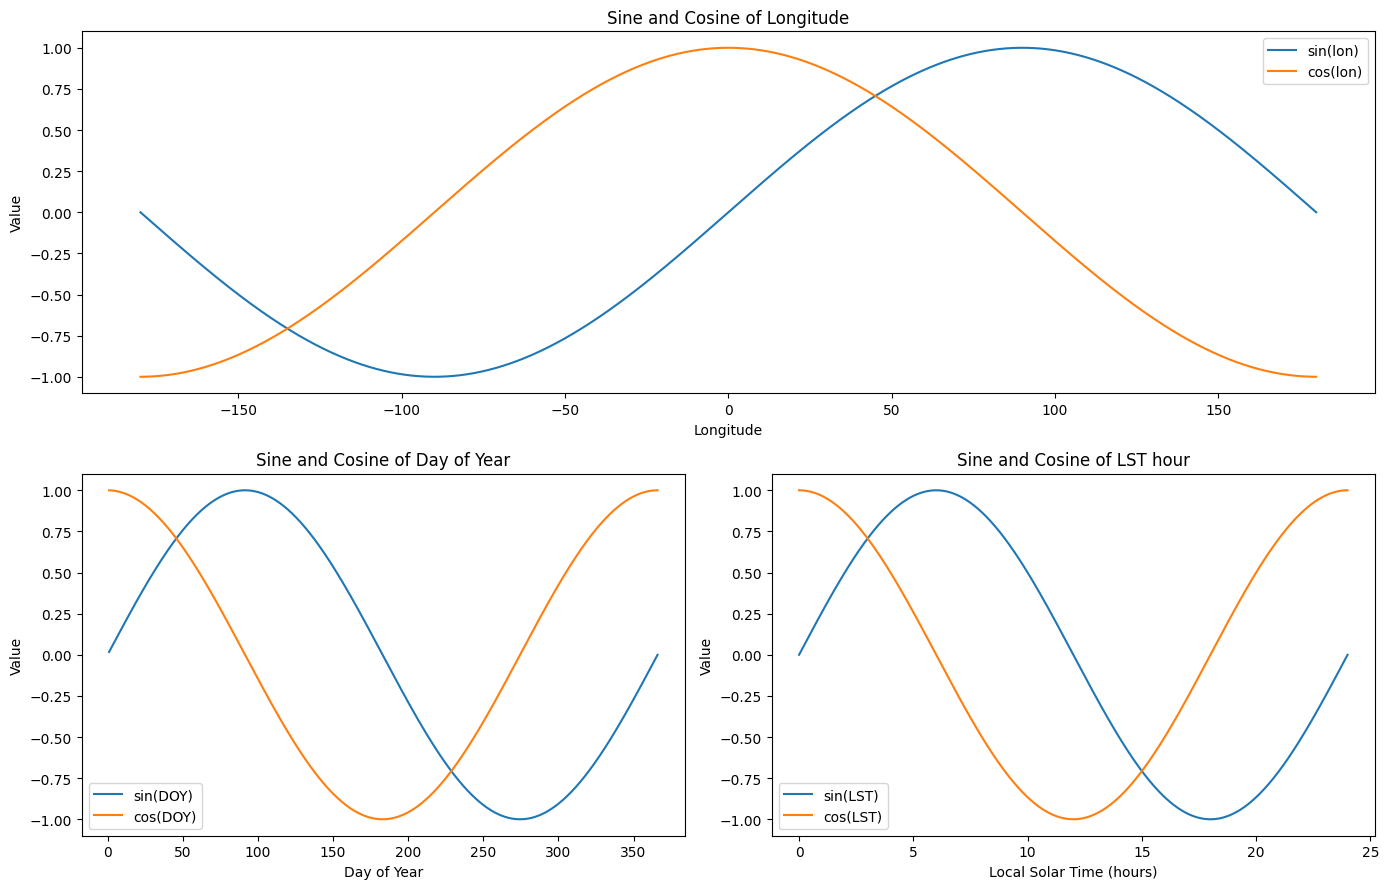

In [44]:
# Sort by the variable so the sine/cosine curves are smooth lines
lon  = np.linspace(-180, 180, 1000)
doy  = np.linspace(1, 366, 1000)
lst  = np.linspace(0, 24, 1000)

fig = plt.figure(figsize=(14, 9))

# Longitude — top, full width
ax0 = fig.add_subplot(2, 1, 1)
ax0.plot(lon, np.sin(np.deg2rad(lon)), label='sin(lon)', color='C0')
ax0.plot(lon, np.cos(np.deg2rad(lon)), label='cos(lon)', color='C1')
ax0.set_xlabel('Longitude'); ax0.set_ylabel('Value')
ax0.set_title('Sine and Cosine of Longitude')
ax0.legend()

# Day of Year — bottom left
ax1 = fig.add_subplot(2, 2, 3)
ax1.plot(doy, np.sin(2*np.pi*doy/366.0), label='sin(DOY)', color='C0')
ax1.plot(doy, np.cos(2*np.pi*doy/366.0), label='cos(DOY)', color='C1')
ax1.set_xlabel('Day of Year'); ax1.set_ylabel('Value')
ax1.set_title('Sine and Cosine of Day of Year')
ax1.legend()

# Local Solar Time — bottom right
ax2 = fig.add_subplot(2, 2, 4)
ax2.plot(lst, np.sin(2*np.pi*lst/24.0), label='sin(LST)', color='C0')
ax2.plot(lst, np.cos(2*np.pi*lst/24.0), label='cos(LST)', color='C1')
ax2.set_xlabel('Local Solar Time (hours)'); ax2.set_ylabel('Value')
ax2.set_title('Sine and Cosine of LST hour')
ax2.legend()

plt.tight_layout()
plt.show()

The (sin, cos) pair gives each point on the cycle a unique position — verify there are no jumps.

## 2. Lagged features

XGBoost sees each row independently — it has no built-in memory of what happened before.
To give it temporal context we add **lagged copies** of a signal: the same value from
some time earlier. Ap is already provided at several lags (`ap_0h`, `ap_m3h`, `ap_m6h`).

The clearest way to understand a lag is to plot the original signal and its lagged copy
on the same time axis — the lagged curve is just the original shifted to the right.

Plot TEC and two lagged copies over a few days — see how each lag shifts the curve.

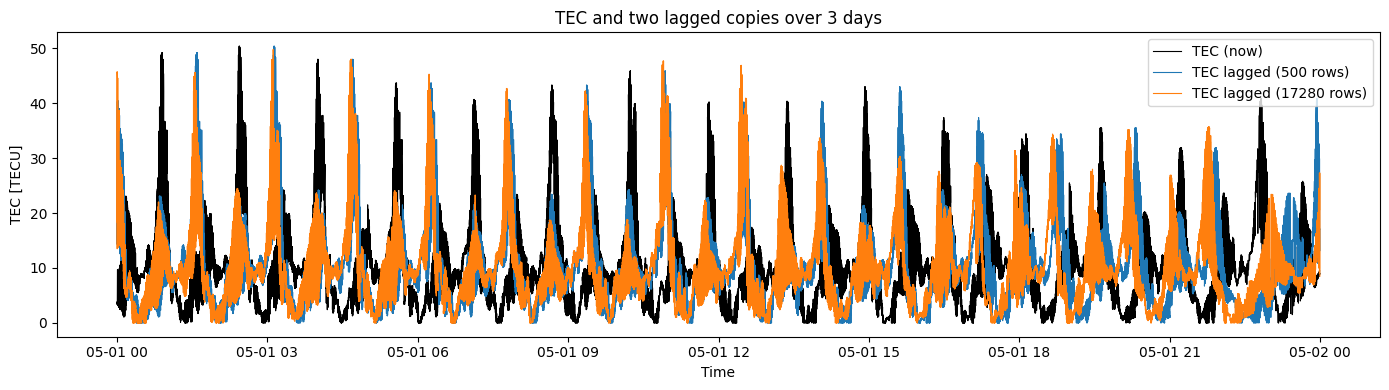

In [47]:
# Build lagged copies of TEC and plot them on the same time axis
df_lag = df.copy()
df_lag['tec_lag_short'] = df_lag['matched_tec_value'].shift(500)
df_lag['tec_lag_long']  = df_lag['matched_tec_value'].shift(17280)

win = df_lag[(df_lag['time'] >= '2010-05-01') & (df_lag['time'] < '2010-05-02')]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(win['time'], win['matched_tec_value'], label='TEC (now)',        color='black', lw=0.8)
ax.plot(win['time'], win['tec_lag_short'],     label='TEC lagged (500 rows)',  color='C0', lw=0.8)
ax.plot(win['time'], win['tec_lag_long'],      label='TEC lagged (17280 rows)', color='C1', lw=0.8)
ax.set_ylabel('TEC [TECU]')
ax.set_xlabel('Time')
ax.set_title('TEC and two lagged copies over 3 days')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Apply all engineering

Call the project's `add_lst_doy_features` function and add the longitude encoding,
TEC lags, and an LST×latitude interaction term. The output lists the new columns.

Apply all transformations: cyclic LST/DOY encoding, longitude encoding, TEC lags, and the LST×latitude interaction term.

In [48]:
df_eng = ff.add_lst_doy_features(df.copy())
df_eng["lon_sin"]           = np.sin(np.deg2rad(df_eng["lon"]))
df_eng["lon_cos"]           = np.cos(np.deg2rad(df_eng["lon"]))
df_eng["lst_lat_sin"]       = df_eng["lst_sin"] * df_eng["lat"]
df_eng["vtec_matched_lag"]  = df_eng["matched_tec_value"].shift(500)
df_eng["vtec_matched_lag2"] = df_eng["matched_tec_value"].shift(17280)
df_eng = df_eng.dropna().reset_index(drop=True)

raw_cols = ["f107", "f107a", "ap_m3h", "ap_m6h", "alt_km", "lat", "lon", "matched_tec_value"]
eng_cols = ["lst_sin", "lst_cos", "doy_sin", "doy_cos", "lon_sin", "lon_cos", "lst_lat_sin",
            "vtec_matched_lag", "vtec_matched_lag2"]

print("Raw features:")
print(raw_cols)
print("\nEngineered features added:")
print(eng_cols)
print(f"\nTotal: {len(raw_cols)} raw  +  {len(eng_cols)} engineered  =  {len(raw_cols)+len(eng_cols)} features")

Raw features:
['f107', 'f107a', 'ap_m3h', 'ap_m6h', 'alt_km', 'lat', 'lon', 'matched_tec_value']

Engineered features added:
['lst_sin', 'lst_cos', 'doy_sin', 'doy_cos', 'lon_sin', 'lon_cos', 'lst_lat_sin', 'vtec_matched_lag', 'vtec_matched_lag2']

Total: 8 raw  +  9 engineered  =  17 features


Plot the main raw features over one week, grouped the way they enter the model.

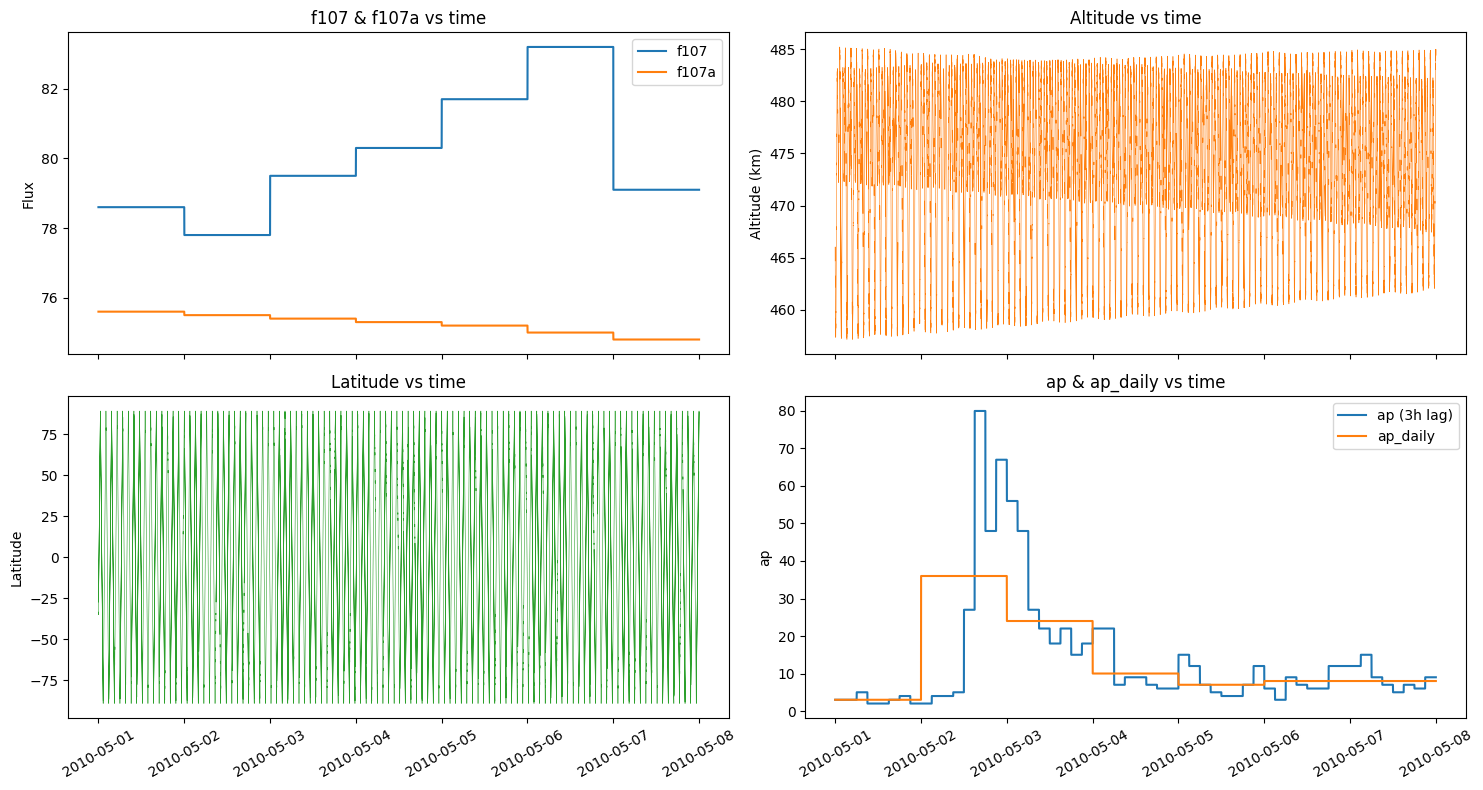

In [49]:
# One week of data so the structure is visible (the full series is too dense)
week = df[(df['time'] >= '2010-05-01') & (df['time'] < '2010-05-08')]

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

# Solar flux
axes[0, 0].plot(week['time'], week['f107'],  label='f107',  color='C0')
axes[0, 0].plot(week['time'], week['f107a'], label='f107a', color='C1')
axes[0, 0].set_ylabel('Flux')
axes[0, 0].set_title('f107 & f107a vs time')
axes[0, 0].legend()

# Altitude
axes[0, 1].plot(week['time'], week['alt_km'], color='C1', lw=0.4)
axes[0, 1].set_ylabel('Altitude (km)')
axes[0, 1].set_title('Altitude vs time')

# Latitude
axes[1, 0].plot(week['time'], week['lat'], color='C2', lw=0.4)
axes[1, 0].set_ylabel('Latitude')
axes[1, 0].set_title('Latitude vs time')
axes[1, 0].tick_params(axis='x', rotation=30)

# Geomagnetic activity
axes[1, 1].plot(week['time'], week['ap_m3h'],   label='ap (3h lag)', color='C0')
axes[1, 1].plot(week['time'], week['ap_daily'], label='ap_daily',    color='C1')
axes[1, 1].set_ylabel('ap')
axes[1, 1].set_title('ap & ap_daily vs time')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Parameters — toggle features and rerun the training cells

Each toggle switches one group of features on or off.  
Rerun from the split cell downward after any change.

In [36]:
# ── PARAMETERS ──────────────────────────────────────────────────────────────
USE_CYCLIC_LST_DOY = True   # False = use raw lst_h / doy instead
USE_LON_ENCODING   = True   # False = use raw lon instead
USE_TEC_LAGS       = True   # False = drop the TEC lag features
USE_LST_LAT_SIN    = True   # False = drop the LST×lat interaction term

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

MAX_DEPTH     = 4
N_ESTIMATORS  = 500
LEARNING_RATE = 0.05
# ────────────────────────────────────────────────────────────────────────────

Build the feature list from the toggles, then split the data.
Note `COLS_TO_SCALE`: only the physical-magnitude features are scaled — the sin/cos
features are already in [-1, 1], so scaling them again would just distort their range.

In [37]:
FEATURES = ['f107', 'f107a', 'ap_m3h', 'ap_m6h', 'alt_km', 'lat', 'matched_tec_value']

if USE_CYCLIC_LST_DOY:
    FEATURES += ['lst_sin', 'lst_cos', 'doy_sin', 'doy_cos']
else:
    FEATURES += ['lst_h', 'doy']

if USE_LON_ENCODING:
    FEATURES += ['lon_sin', 'lon_cos']
else:
    FEATURES += ['lon']

if USE_TEC_LAGS:
    FEATURES += ['vtec_matched_lag', 'vtec_matched_lag2']

if USE_LST_LAT_SIN:
    FEATURES += ['lst_lat_sin']

# Only the physical-magnitude features need scaling.
# The sin/cos features are already bounded in [-1, 1] by construction, so we leave them as-is.
COLS_TO_SCALE = ['f107', 'f107a', 'ap_m3h', 'ap_m6h', 'alt_km', 'lat',
                 'matched_tec_value', 'vtec_matched_lag', 'vtec_matched_lag2', 'lst_h', 'doy']
COLS_TO_SCALE = [c for c in COLS_TO_SCALE if c in FEATURES]

# Temporal split on the engineered dataframe (same 70/15/15 as NB1)
n = len(df_eng)
n_train = int(n * TRAIN_FRAC)
n_val   = int(n * (TRAIN_FRAC + VAL_FRAC))

train_df = df_eng.iloc[:n_train]
val_df   = df_eng.iloc[n_train:n_val]
test_df  = df_eng.iloc[n_val:]

print(f'Train {len(train_df):,}  Val {len(val_df):,}  Test {len(test_df):,}')
print(f'Using {len(FEATURES)} features, scaling {len(COLS_TO_SCALE)} of them')

Train 2,777,018  Val 595,075  Test 595,076
Using 16 features, scaling 9 of them


Scale features and train XGBoost with the active feature set.

In [38]:
# Scale only the magnitude features; pass the bounded sin/cos features through unchanged.
scaler_X = MinMaxScaler(feature_range=(-1, 1)).fit(train_df[COLS_TO_SCALE])

def scale_X(d):
    out = d[FEATURES].copy()
    out[COLS_TO_SCALE] = scaler_X.transform(d[COLS_TO_SCALE])
    return out.values

X_train = scale_X(train_df)
X_val   = scale_X(val_df)
X_test  = scale_X(test_df)

# Target is a single magnitude column, so it does get scaled
scaler_y = MinMaxScaler(feature_range=(-1, 1))
y_train = scaler_y.fit_transform(train_df[['log_ratio']]).ravel()
y_val   = scaler_y.transform(val_df[['log_ratio']]).ravel()
y_test  = scaler_y.transform(test_df[['log_ratio']]).ravel()

model = xgb.XGBRegressor(
    max_depth=MAX_DEPTH,
    n_estimators=N_ESTIMATORS,
    learning_rate=LEARNING_RATE,
    subsample=0.5,
    colsample_bytree=0.6,
    min_child_weight=300,
    tree_method='hist',
    n_jobs=-1,
    early_stopping_rounds=20,
    verbosity=0,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f'Best iteration: {model.best_iteration}')

Best iteration: 53


Convert predictions back to density and compute the train/val/test RMSE.

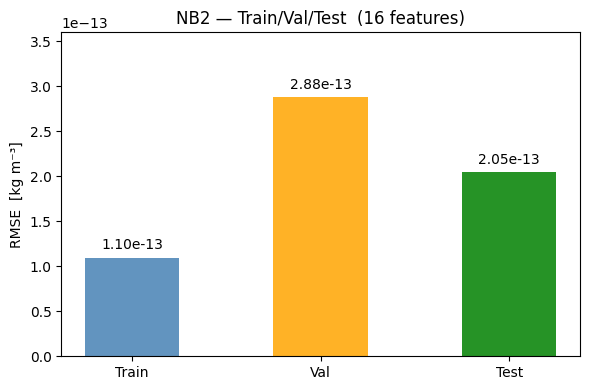

Train 1.096e-13  |  Val 2.881e-13  |  Test 2.046e-13


In [39]:
# Convert predictions back to physical density: rho = rho_msis * exp(log_ratio)
def to_density(df_split, X_split):
    log_ratio = scaler_y.inverse_transform(model.predict(X_split).reshape(-1, 1)).ravel()
    return df_split['msis_rho'].values * np.exp(log_ratio)

rho_pred_train = to_density(train_df, X_train)
rho_pred_val   = to_density(val_df,   X_val)
rho_pred_test  = to_density(test_df,  X_test)

rmse_train = root_mean_squared_error(train_df['rho_obs'].values, rho_pred_train)
rmse_val   = root_mean_squared_error(val_df['rho_obs'].values,   rho_pred_val)
rmse_test  = root_mean_squared_error(test_df['rho_obs'].values,  rho_pred_test)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Train', 'Val', 'Test'], [rmse_train, rmse_val, rmse_test],
              color=['steelblue', 'orange', 'green'], alpha=0.85, width=0.5)
ax.bar_label(bars, fmt='{:.2e}', padding=4)
ax.set_ylabel('RMSE  [kg m⁻³]')
ax.set_title(f'NB2 — Train/Val/Test  ({len(FEATURES)} features)')
ax.set_ylim(0, max(rmse_train, rmse_val, rmse_test) * 1.25)
plt.tight_layout()
plt.show()

print(f'Train {rmse_train:.3e}  |  Val {rmse_val:.3e}  |  Test {rmse_test:.3e}')

Plot how much each feature contributed to reducing prediction error (gain).

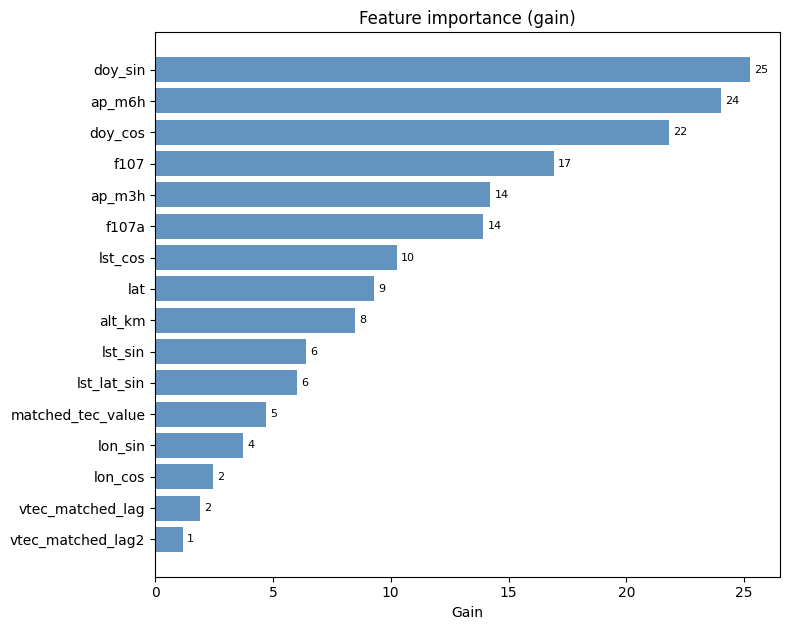

In [40]:
# get_score returns XGBoost's internal names (f0, f1, ...) because we trained on a
# NumPy array. Map them back to the real feature names via their column position.
importance = model.get_booster().get_score(importance_type='gain')
gain_by_name = {FEATURES[int(k[1:])]: v for k, v in importance.items()}

imp_df = (pd.DataFrame(gain_by_name.items(), columns=['feature', 'gain'])
            .sort_values('gain'))

fig, ax = plt.subplots(figsize=(8, max(4, len(imp_df) * 0.4)))
bars = ax.barh(imp_df['feature'], imp_df['gain'], color='steelblue', alpha=0.85)
ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
ax.set_xlabel('Gain')
ax.set_title('Feature importance (gain)')
plt.tight_layout()
plt.show()

Compute RMSE, MAPE, and R² in physical density space for MSIS and the model.

In [41]:
from sklearn.metrics import r2_score

def density_metrics(rho_obs, rho_pred, label):
    mask = rho_obs > 0
    obs, pred = rho_obs[mask], rho_pred[mask]
    rmse = np.sqrt(np.mean((obs - pred) ** 2))
    mape = np.mean(np.abs((obs - pred) / obs)) * 100
    r2   = r2_score(obs, pred)
    return {'Model': label, 'RMSE [kg/m³]': f'{rmse:.3e}',
            'MAPE [%]': f'{mape:.1f}', 'R²': f'{r2:.3f}'}

rows = [
    density_metrics(val_df['rho_obs'].values,  val_df['msis_rho'].values,  'MSIS — Val'),
    density_metrics(val_df['rho_obs'].values,  rho_pred_val,                'Model — Val'),
    density_metrics(test_df['rho_obs'].values, test_df['msis_rho'].values, 'MSIS — Test'),
    density_metrics(test_df['rho_obs'].values, rho_pred_test,               'Model — Test'),
]
pd.DataFrame(rows).set_index('Model')

,RMSE [kg/m³],MAPE [%],R²
Model,,,
MSIS — Val,2.639e-13,12.9,0.923
Model — Val,2.881e-13,12.7,0.908
MSIS — Test,2.667e-13,25.9,0.814
Model — Test,2.046e-13,17.3,0.891


## Try this

Compare the bar chart and metrics table with the values you got in NB1.

Toggle one feature group at a time in the Parameters cell, then rerun from the split cell:
- `USE_CYCLIC_LST_DOY = False` — back to raw `lst_h` / `doy`
- `USE_TEC_LAGS = False` — drop the lag features
- `USE_LST_LAT_SIN = False` — drop the interaction term

Which group changes the val score the most? Does the feature importance chart
agree with what the correlation plots suggested?

In **NB3** we keep these features but change how the data is split.